ANALISIS ESTADISTICO.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [11]:
import sys
sys.path.append("./src")

from soporte_correlacion import matriz_correlacion_visual

In [2]:
df_clean =pd.read_csv("files/df_clean.csv")

In [ ]:
df_clean.describe().T #analizamos las estadisticas descriptivas.

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Flights with Companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
Total Flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Points Redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00


en general los datos muestran una distribucion desigual en varias variables, donde  se presentan valores mas altos, vuelos, cantidad de vuelos, distancias,podria indicar distintos perfiles de clientes.
Respecto a la columna salario se contempla compo se vio anteriormente la presencia de outliners , se ha arreglado los valores negativos, en la columna clv el maximo es mas significativo que el resto,

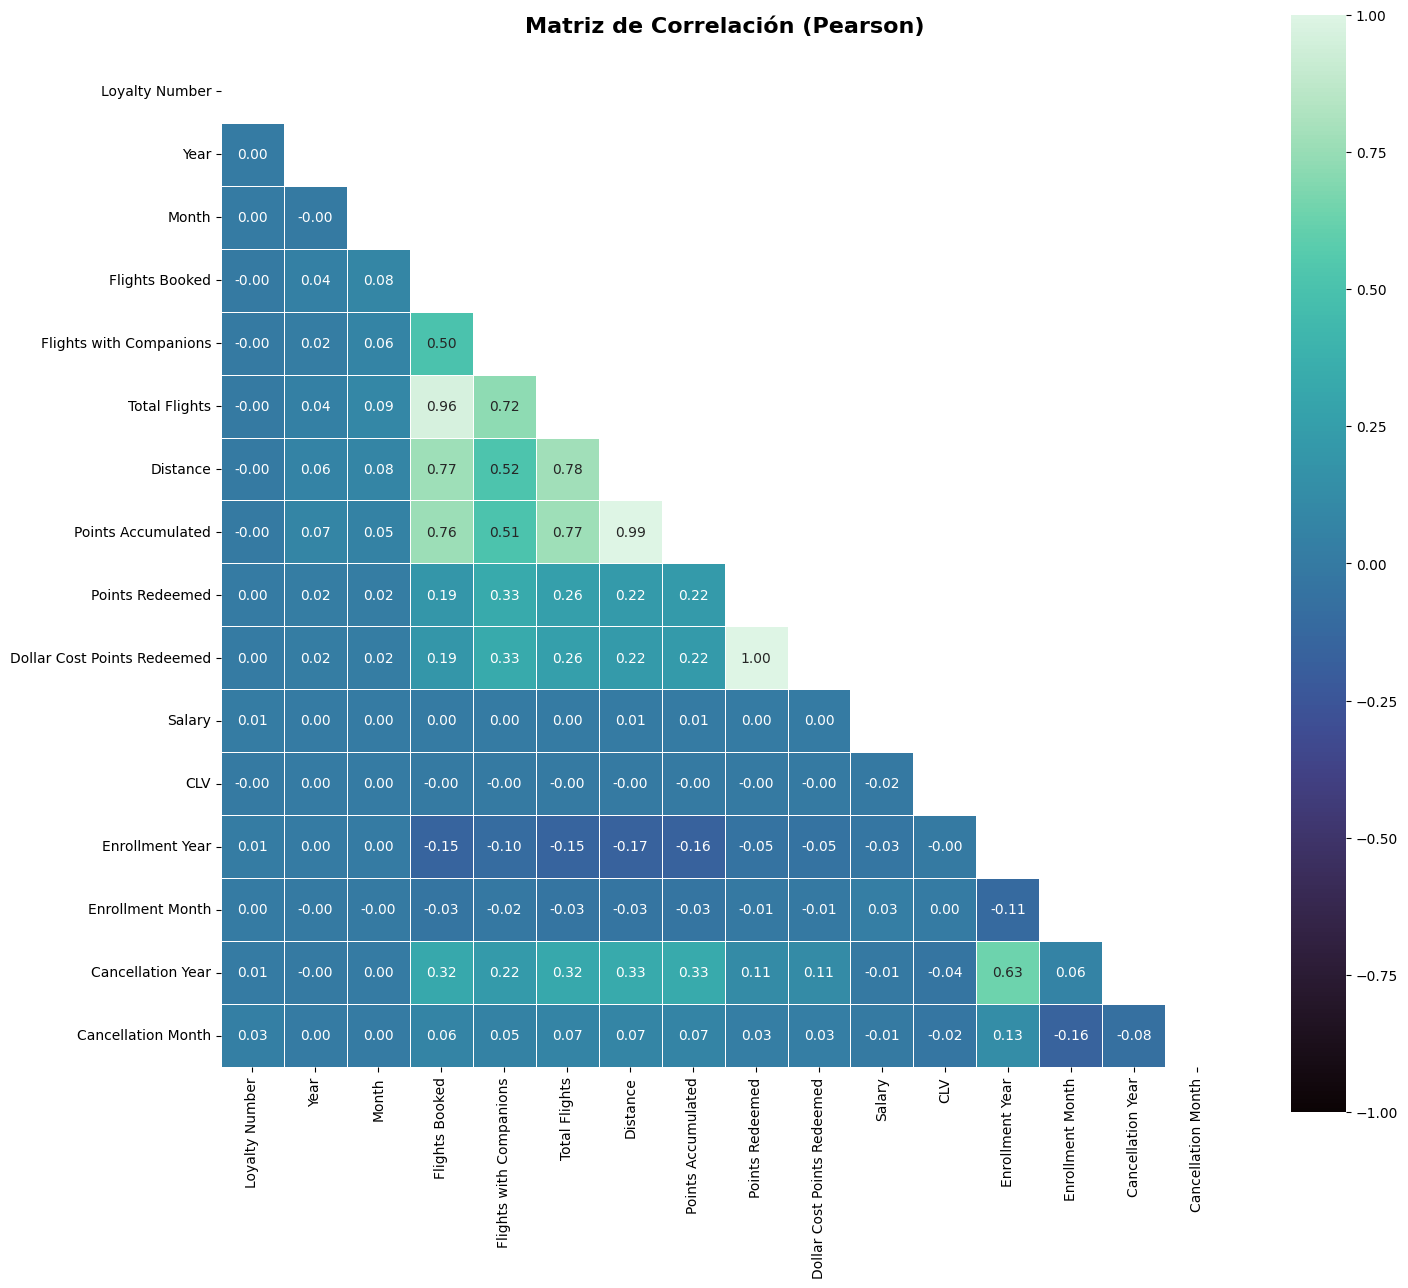

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
Loyalty Number,1.000000,0.000391,0.000199,-0.002280,-0.003069,-0.002805,-0.001779,-0.001792,0.000647,0.000641,0.011677,-0.000625,0.008209,0.004877,0.007354,0.033378
Year,0.000391,1.000000,-0.000025,0.044121,0.021327,0.042153,0.055767,0.074910,0.017503,0.017495,0.000087,0.000187,0.000500,-0.000243,-0.000044,0.000431
Month,0.000199,-0.000025,1.000000,0.082137,0.064486,0.086373,0.076321,0.054066,0.019361,0.019267,0.000041,0.000051,0.000211,-0.000120,0.000032,0.000099
Flights Booked,-0.002280,0.044121,0.082137,1.000000,0.501698,0.961233,0.766748,0.759547,0.187638,0.187647,0.004657,-0.002847,-0.153305,-0.031550,0.316053,0.064853
Flights with Companions,-0.003069,0.021327,0.064486,0.501698,1.000000,0.720773,0.517188,0.510284,0.334000,0.334060,0.001614,-0.002510,-0.096835,-0.019639,0.220471,0.049511
Total Flights,-0.002805,0.042153,0.086373,0.961233,0.720773,1.000000,0.779262,0.771291,0.256821,0.256848,0.004246,-0.003081,-0.153712,-0.031542,0.316461,0.066162
Distance,-0.001779,0.055767,0.076321,0.766748,0.517188,0.779262,1.000000,0.994546,0.223707,0.223728,0.006674,-0.004132,-0.165141,-0.034449,0.330539,0.070337
Points Accumulated,-0.001792,0.074910,0.054066,0.759547,0.510284,0.771291,0.994546,1.000000,0.222674,0.222707,0.006584,-0.000942,-0.164520,-0.033923,0.332410,0.069457
Points Redeemed,0.000647,0.017503,0.019361,0.187638,0.334000,0.256821,0.223707,0.222674,1.000000,0.999972,0.001977,-0.000265,-0.047759,-0.008680,0.112523,0.026184
Dollar Cost Points Redeemed,0.000641,0.017495,0.019267,0.187647,0.334060,0.256848,0.223728,0.222707,0.999972,1.000000,0.001971,-0.000238,-0.047808,-0.008683,0.112596,0.026154


In [12]:
matriz_correlacion_visual(df_clean)

Destaca alta correlacion entre el numero de vuelos reservados y total de vuelos lo que indica que ambas estan estrechamente relacionadas,pasa igual entre distancia recorrida y puntos acumulados luego salario y cvc no presentan correlaciones significativas con lo que con lo que se intuye que no influye directamente con el comportamiento del vuelo de los clientes.

In [5]:
df_clean.describe(include="str")

,Province,City,Postal Code,Gender,Education,Marital Status,Loyalty Card,Enrollment Type
count,403760,403760,403760,403760,403760,403760,403760,403760
unique,11,29,55,2,5,3,3,2
top,Ontario,Toronto,V6E 3D9,Female,Bachelor,Married,Star,Standard
freq,130258,80775,21944,202757,252567,234845,183745,380419


aqui podemos ver que la mayoria se concentran en la ciudad de toronto la porvincia de ontario,hay mas mujeres  el nivel de estudios predominante es bachiller, predominan los casados.en la columna enrolment type la gran mayoria del total usaron standard.respecto al codifo postal de los 55 valores distintos gran parte se concentra en uno.

In [ ]:
df_clean["City"].value_counts().head(29) #PREDOMINA TORONTO,VANCOUVER Y MONTREAL

City
Toronto           80775
Vancouver         62314
Montreal          49687
Winnipeg          15900
Whistler          13994
Halifax           12507
Ottawa            12262
Edmonton          11768
Trenton           11710
Quebec City       11698
Dawson Creek      10725
Fredericton       10266
Regina             9861
Kingston           9652
Tremblant          9576
Victoria           9444
Hull               8612
West Vancouver     7831
St. John's         6244
Thunder Bay        6171
Sudbury            5493
Moncton            5086
Calgary            4584
Banff              4296
London             4195
Peace River        2712
Whitehorse         2679
Kelowna            2134
Charlottetown      1584
Name: count, dtype: int64

In [ ]:
df_clean["Province"].value_counts().head(11) #Y DE PROVINCIA ONTARIO,BRITISH COLUMBIA Y QUEBEC.

Province
Ontario                 130258
British Columbia        106442
Quebec                   79573
Alberta                  23360
Manitoba                 15900
New Brunswick            15352
Nova Scotia              12507
Saskatchewan              9861
Newfoundland              6244
Yukon                     2679
Prince Edward Island      1584
Name: count, dtype: int64

In [ ]:
cols = ["Education", "Gender", "Marital Status", "Loyalty Card"] #pasamos analizar los valores de las categoricas que no tienen tantos valores unicos.

for col in cols:
    print("\n", col)
    print(df_clean[col].value_counts(normalize=True))


 Education
Education
Bachelor                0.625537
College                 0.253269
High School or Below    0.046847
Doctor                  0.043915
Master                  0.030431
Name: proportion, dtype: float64

 Gender
Gender
Female    0.502172
Male      0.497828
Name: proportion, dtype: float64

 Marital Status
Marital Status
Married     0.581645
Single      0.267865
Divorced    0.150490
Name: proportion, dtype: float64

 Loyalty Card
Loyalty Card
Star      0.455085
Nova      0.339021
Aurora    0.205895
Name: proportion, dtype: float64


conclusiones:el perfil predominante a nivel educativo corresponde a bachiller, respecto a hombres y mujeres esta bastante igualado siendo un poco superior por mujeres,tambien nos revela que hay mayor porcentaje de casados casi el doble, y respecto a la tarjeta de fidelidad predomina la start.